# 04 - Segmentation

Tujuan untuk memisahkan objek sampah dari background sehingga informasi visual yang tidak relevan dapat dikurangi sebelum proses ekstraksi fitur dan pemodelan CNN

In [1]:
import sys
from pathlib import Path
project_root = Path('..').resolve()
sys.path.append(str(project_root / 'src'))
import cv2, numpy as np, matplotlib.pyplot as plt
from segmentation import (
    otsu_segmentation,
    hsv_segmentation,
    grabcut_segmentation,
    kmeans_segmentation,
    ensemble_pipeline,
    foreground_ratio,
)

plt.rcParams['figure.figsize'] = (10,6)

..\data\enhanced\clahe\val\biological\biological_102.jpg


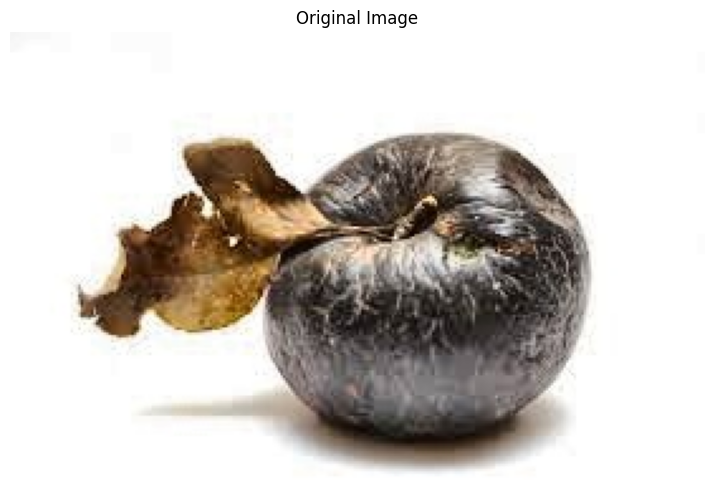

In [2]:
from pathlib import Path

sample_path = next(
    (Path("..") / "data" / "enhanced" / "clahe" / "val").rglob("*.jpg"),
    None
)
print(sample_path)

img = cv2.imread(str(sample_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original Image")
plt.show()

### Perbandingan Metode Segementasi

In [3]:
mask_otsu = otsu_segmentation(img)
mask_hsv = hsv_segmentation(img)
mask_gc = grabcut_segmentation(img)
mask_kmeans = kmeans_segmentation(img)

C:\Johanna\SEM6\PCD\project\waste-classification-cnn\src\segmentation.py:21: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = morphology.remove_small_objects(mask.astype(bool), 500)
C:\Johanna\SEM6\PCD\project\waste-classification-cnn\src\segmentation.py:35: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask 

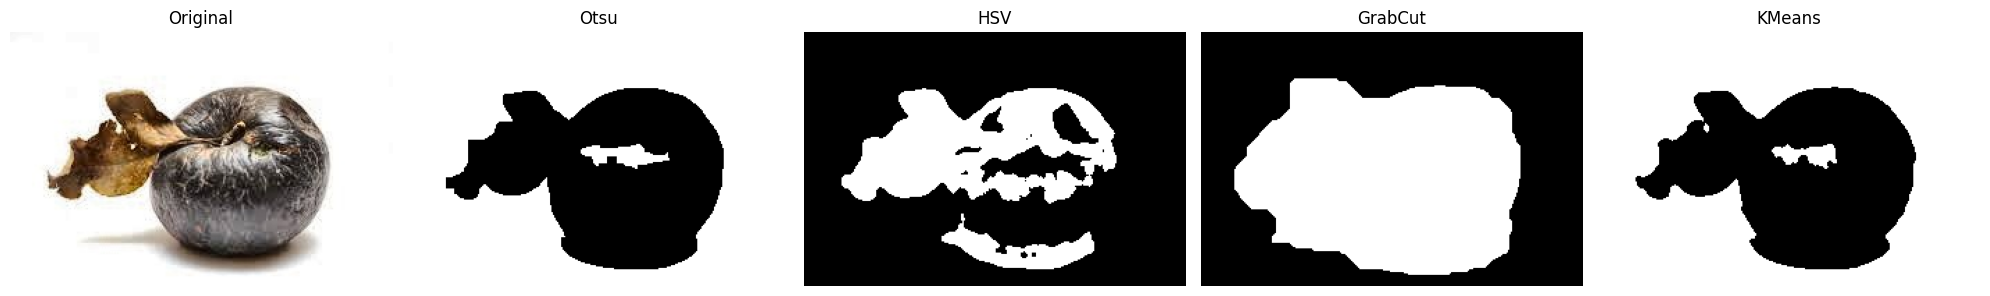

In [13]:
fig, ax = plt.subplots(1,5, figsize=(20,5))

ax[0].imshow(img_rgb)
ax[0].set_title("Original")

ax[1].imshow(mask_otsu, cmap="gray")
ax[1].set_title("Otsu")

ax[2].imshow(mask_hsv, cmap="gray")
ax[2].set_title("HSV")

ax[3].imshow(mask_gc, cmap="gray")
ax[3].set_title("GrabCut")

ax[4].imshow(mask_kmeans, cmap="gray")
ax[4].set_title("KMeans")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()

* Metode Otsu menghasilkan segmentasi yang kurang stabil karena sensitif terhadap variasi pencahayaan dan kompleksitas background.
* Metode HSV mampu mendeteksi objek berdasarkan karakteristik warna namun masih menghasilkan noise pada beberapa citra.
* GrabCut memberikan segmentasi yang lebih baik dengan memanfaatkan distribusi warna dan informasi spasial

### Pipeline Ensemble

Metode Ensemble yang menggabungkan HSV, GrabCut, dan operasi morfologi menghasilkan segmentasi yang paling konsisten sehingga dipilih sebagai metode segmentasi utama untuk tahap klasifikasi CNN.

In [5]:
init, refined, final, segmented = ensemble_pipeline(
    img,
    return_segmented=True
)

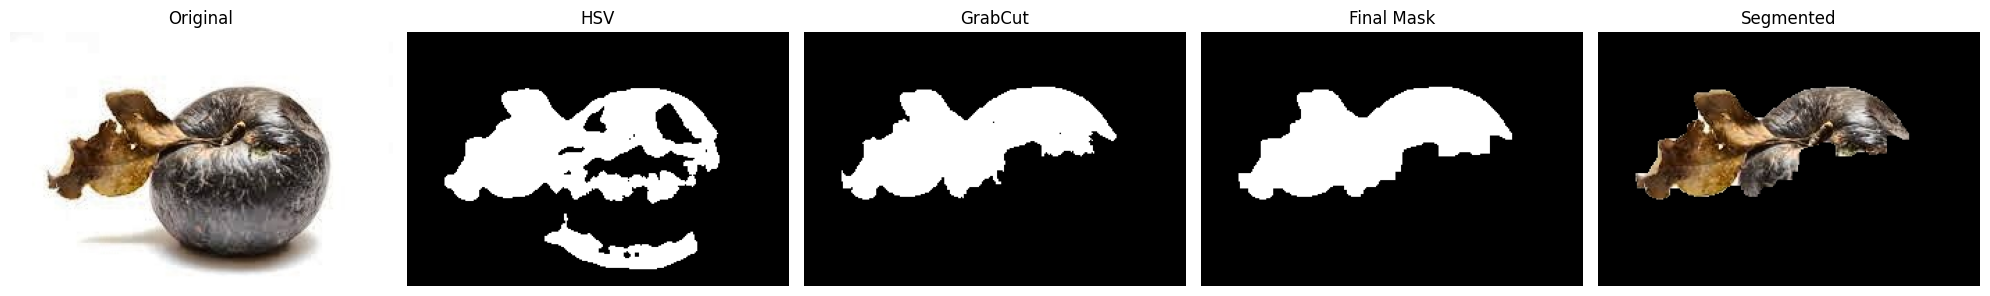

In [6]:
fig, ax = plt.subplots(1,5, figsize=(20,5))

ax[0].imshow(img_rgb)
ax[0].set_title("Original")

ax[1].imshow(init, cmap="gray")
ax[1].set_title("HSV")

ax[2].imshow(refined, cmap="gray")
ax[2].set_title("GrabCut")

ax[3].imshow(final, cmap="gray")
ax[3].set_title("Final Mask")

ax[4].imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
ax[4].set_title("Segmented")

for a in ax:
    a.axis("off")

plt.tight_layout()

### Foreground Ratio

In [7]:
print(
    "Foreground Ratio:",
    round(foreground_ratio(final), 3)
)

Foreground Ratio: 0.18


Artinya, sekitar 34.2% area citra dianggap sebagai objek utama, sisanya merupakan background

### Uji 5 Sampel Acak

In [8]:
import random

image_paths = list(
    (Path("..") / "data" / "enhanced" / "clahe" / "val").rglob("*.jpg")
)

samples = random.sample(
    image_paths,
    min(5, len(image_paths))
)

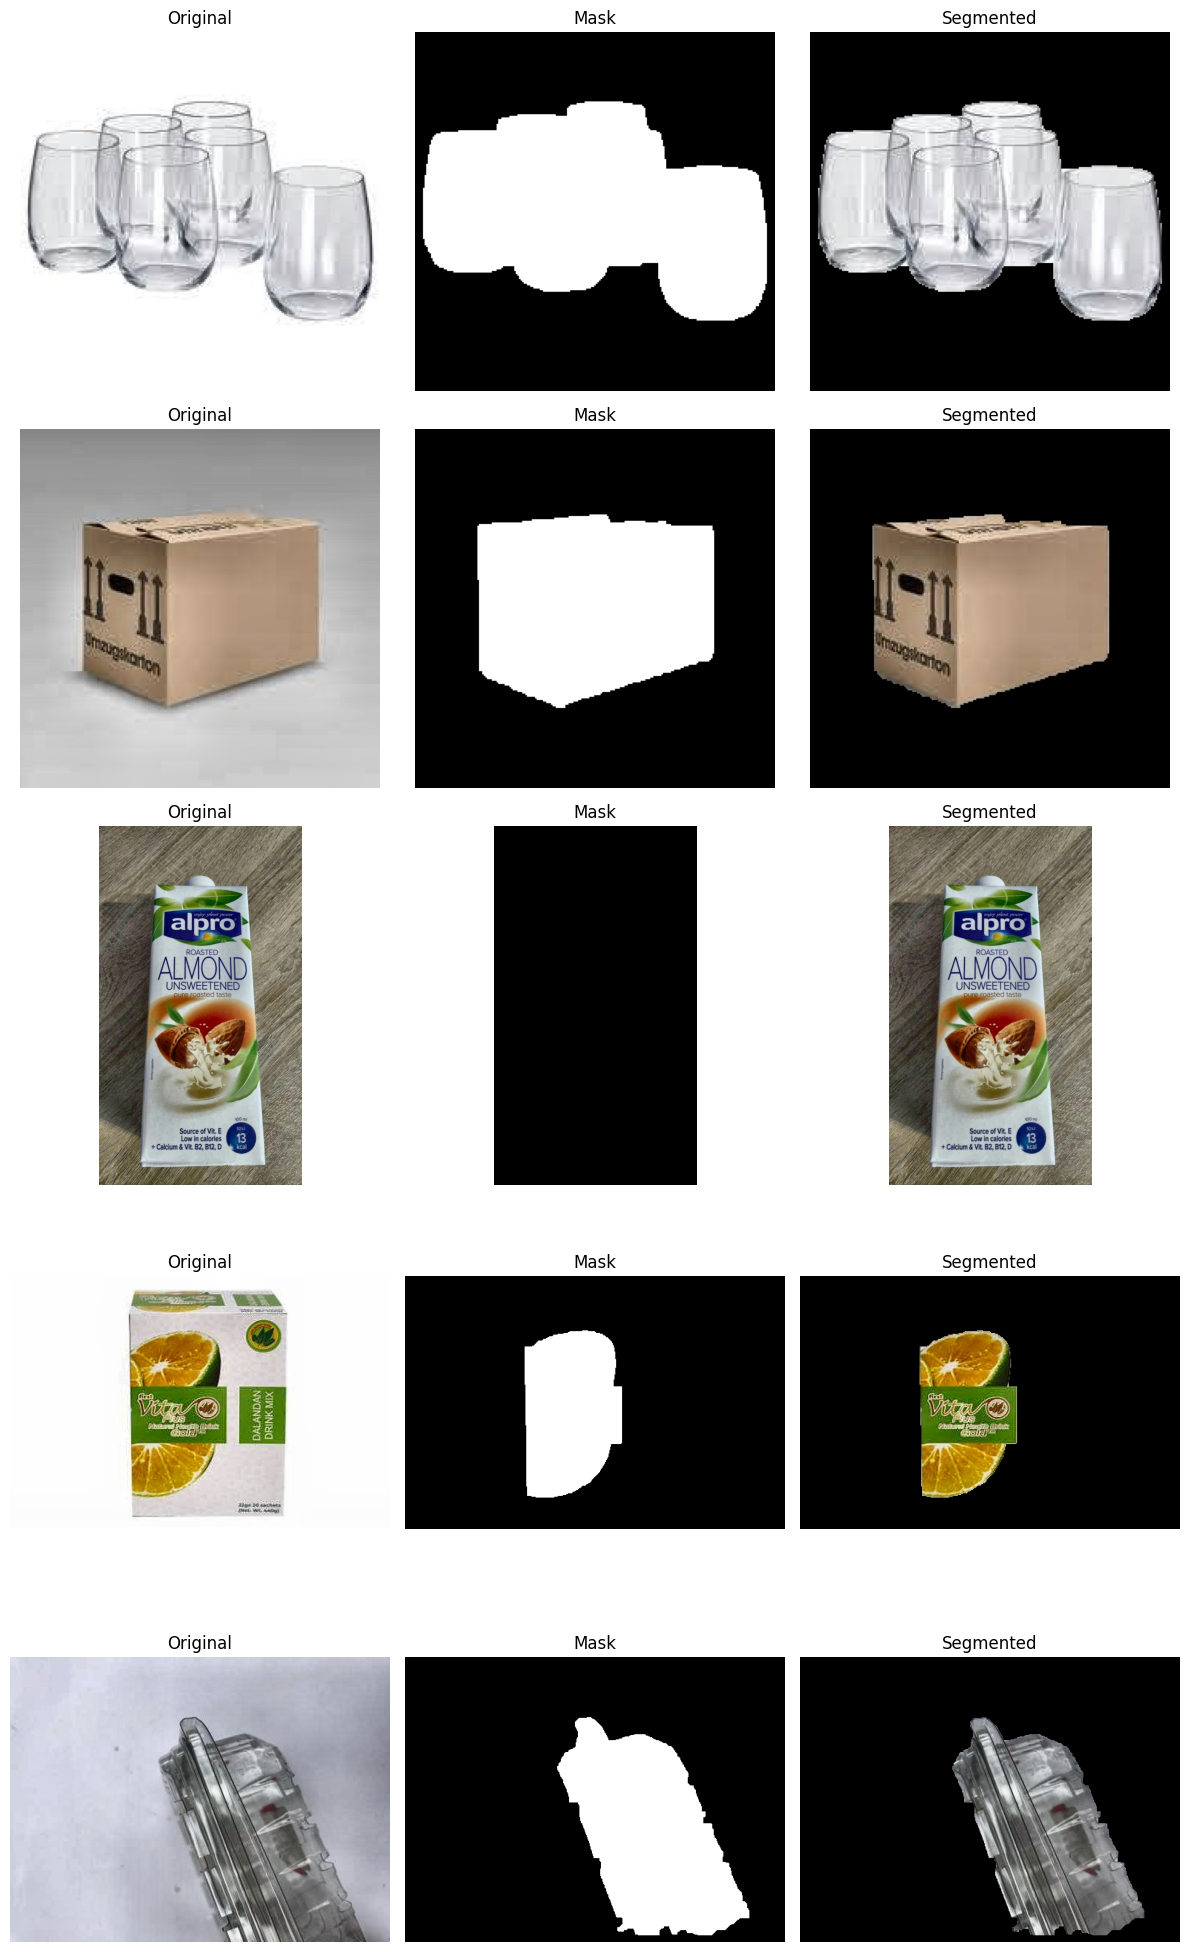

In [10]:
fig, ax = plt.subplots(len(samples), 3, figsize=(12, 4*len(samples)))

for i, img_path in enumerate(samples):

    img = cv2.imread(str(img_path))

    _, _, final, segmented = ensemble_pipeline(
        img,
        return_segmented=True
    )

    ax[i,0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[i,0].set_title("Original")

    ax[i,1].imshow(final, cmap="gray")
    ax[i,1].set_title("Mask")

    ax[i,2].imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
    ax[i,2].set_title("Segmented")

    for j in range(3):
        ax[i,j].axis("off")

plt.tight_layout()
plt.show()